In [ ]:
import pandas as pd
import re
import numpy as np

# Data Loading and Merging

## 1. Data Loading and Merging

Se cargan tres fuentes de datos:

- **`partidos.csv`** — estadísticas de partidos scrapeadas de FlashScore
- **`ranking_fifa.csv`** — puntos FIFA por selección y fecha
- **`transfermarkt.csv`** — valor de mercado de cada selección

Se eliminan duplicados exactos por la clave compuesta `(URL, Fecha, Equipo_Local, Equipo_Visitante)` y se filtra el dataset para conservar únicamente partidos donde participe al menos una de las 50 selecciones clasificadas al Mundial 2026.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Simulaciones_Mundial/Data'
df = pd.read_csv(f'{base_path}/partidos.csv')
df_ranking = pd.read_csv(f'{base_path}/ranking_fifa.csv')
df_transfermarkt = pd.read_csv(f'{base_path}/transfermarkt.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_4997/187033869.py:5: DtypeWarning: Columns (42,43,44,45,46,47,54,55,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312

In [ ]:
# Check no duplicates
print(df.shape)
df.drop_duplicates(subset=['URL', 'Fecha', 'Equipo_Local', 'Equipo_Visitante'], keep='last', inplace=True)
print(df.shape)

(3316, 2778)
(3316, 2778)


### Selecciones que juegan el mundial

Vamos a quedarnos solo con partidos en donde haya jugado al menos una de las selecciones que juegan el Mundial.

In [ ]:
equipos_mundial = [
    'Alemania', 'Austria', 'Bélgica', 'Bosnia-Herzegovina', 'Croacia',
    'Escocia', 'España', 'Francia', 'Inglaterra', 'Noruega',
    'Países Bajos', 'Portugal', 'República Checa', 'Suecia', 'Suiza', 'Turquía',

    'Argentina', 'Brasil', 'Colombia', 'Ecuador', 'Paraguay', 'Uruguay',
    'Canadá', 'Curazao', 'EE. UU.', 'Haití', 'México', 'Panamá',

    'Argelia', 'Cabo Verde', 'Costa de Marfil', 'Egipto', 'Ghana',
    'Marruecos', 'RD Congo', 'Senegal', 'Sudáfrica', 'Túnez',

    'Arabia Saudí', 'Australia', 'Catar', 'Corea del Sur', 'Irak',
    'Irán', 'Japón', 'Jordania', 'Uzbekistán',
    'Nueva Zelanda'
]

df = df[df['Equipo_Local'].isin(equipos_mundial) | df['Equipo_Visitante'].isin(equipos_mundial)]

print(df.shape)

(1660, 2778)


In [ ]:
# Gestion amistosos en fecha de Mundial
df.loc[(df['Equipo_Local'] == 'Bolivia') & (df['Fecha'] == '11.06.2026 02:00'), 'Fecha'] = '10.06.2026 02:00'

## Join ranking FIFA

## 2. Join Ranking FIFA (`merge_asof`)

El ranking FIFA se publica periódicamente, no partido a partido. Para asignar a cada partido los puntos FIFA vigentes en ese momento sin filtrar información futura, se usa un **left join temporal hacia atrás**:

$$\text{Puntos\_Local}_{t} = \text{Puntos\_FIFA}_{s^*}, \quad s^* = \max\{s \in \mathcal{R} : s < t\}$$

donde $\mathcal{R}$ es el conjunto de fechas de publicación del ranking. Esto se implementa con:

```python
pd.merge_asof(..., direction='backward', allow_exact_matches=False)
```

aplicado dos veces: una para el local y otra para el visitante. Antes del join se homogenizan los nombres de países entre ambas fuentes mediante un diccionario de mapeo.

Vamos a crear un diccionario para poder hacer el join de los datos de FlashScore y el ranking FIFA.

In [ ]:
# CLAVE = Nombre en df_ranking (El que queremos cambiar)
# VALOR = Nombre en df_partidos (El que queremos conservar)
mapeo_paises = {
    'EEUU': 'EE. UU.',
    'RI de Irán': 'Irán',
    'República de Corea': 'Corea del Sur',
    'RD del Congo': 'RD Congo',
    'Bosnia y Herzegovina': 'Bosnia-Herzegovina',
    'Baréin': 'Bahréin',
    'RP China': 'China',
    'República Kirguisa': 'Kirguistán',
    'Kazajstán': 'Kazajistán',
    'RDP de Corea': 'Corea del Norte',
    'Guinea-Bissáu': 'Guinea-Bisáu',
    'San Cristóbal y Nieves': 'Saint Kitts y Nevis',
    'Hong Kong, China': 'Hong Kong',
    'Myanmar': 'Birmania',
    'Esuatini': 'Eswatini',
    'Chinese Taipei': 'China Taipei',
    'Bangladesh': 'Bangladés',
    'Samoa Estadounidense': 'Samoa Americana',
    'Brunéi Darussalam': 'Brunéi',
    'República de Irlanda': 'Irlanda',
    'Qatar': 'Catar',
    'Turcas y Caicos': 'Islas Turcas y Caicos',
    'Antigua y Barbuda': 'Antigua & Barbuda',
    'Comoras': 'Comores'
}

# Aplicar el reemplazo en la columna del df_ranking
df_ranking['País'] = df_ranking['País'].replace(mapeo_paises)

# Comprobar si ha quedado algún país "huérfano"
paises_df = set(df['Equipo_Local'].unique()).union(set(df['Equipo_Visitante'].unique()))
paises_ranking = set(df_ranking['País'].unique())

huérfanos = paises_df - paises_ranking

if huérfanos:
    print(f"ATENCIÓN: Hay {len(huérfanos)} países que NO tienen ranking FIFA asociado:")
    print(sorted(list(huérfanos)))
else:
    print("Éxito! Todos los países de tus partidos tienen su correspondencia exacta en el ranking FIFA.")

ATENCIÓN: Hay 4 países que NO tienen ranking FIFA asociado:
['Guadalupe', 'Saint Martin', 'Sint Maarten', 'Urartu']


Unificamos las fechas para el JOIN.

In [ ]:
# Gestion de la fecha
# Convierte la columna al formato datetime de Pandas reconociendo los puntos y la hora
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y %H:%M')

# (Opcional) Si la hora no te aporta nada y quieres quedarte solo con la fecha limpia (YYYY-MM-DD)
df['Fecha'] = df['Fecha'].dt.normalize()
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

# Cambiamos el formato de la fecha a YYYY-MM-DD
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha'], format='%d-%m-%Y')
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha']).dt.strftime('%Y-%m-%d')

# Forzar la conversión de ambas columnas a datetime puro
df['Fecha'] = pd.to_datetime(df['Fecha']).dt.tz_localize(None)
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha']).dt.tz_localize(None)

In [ ]:
# ORDENAR por fecha (Obligatorio para merge_asof)
df = df.sort_values('Fecha').reset_index(drop=True)
df_ranking = df_ranking.sort_values('Fecha').reset_index(drop=True)

# ==========================================
# PASO 1: Cruzar ranking del EQUIPO LOCAL
# ==========================================
df = pd.merge_asof(
    df,
    df_ranking,
    on='Fecha',               # Como se llama igual en ambos, usamos simplemente 'on'
    left_by='Equipo_Local',
    right_by='País',
    direction='backward',
    allow_exact_matches=False
)

# Renombramos SOLO los datos del ranking, dejando la 'Fecha' intacta
df = df.rename(columns={
    'Puntuación': 'Puntos_Local'  # O la variable que tengas de puntos
})

# ==========================================
# PASO 2: Cruzar ranking del EQUIPO VISITANTE
# ==========================================
df = pd.merge_asof(
    df,
    df_ranking,
    on='Fecha',               # La columna 'Fecha' sigue ahí, lista para usarse
    left_by='Equipo_Visitante',
    right_by='País',
    direction='backward',
    allow_exact_matches=False
)

# Renombramos los datos del Visitante
df = df.rename(columns={
    'Puntuación': 'Puntos_Visitante'
})

# Opcional: Como el 'País' del df_ranking se nos pegará dos veces, lo limpiamos
columnas_a_borrar = [col for col in df.columns if 'País' in col]
df = df.drop(columns=columnas_a_borrar)

# Comprobamos el JOIN
print(df[['Fecha', 'Equipo_Local', 'Puntos_Local', 'Equipo_Visitante', 'Puntos_Visitante']].head())

       Fecha  Equipo_Local  Puntos_Local Equipo_Visitante  Puntos_Visitante
0 2019-09-05  China Taipei        1134.0         Jordania            1196.0
1 2019-09-05     Palestina        1236.0       Uzbekistán            1251.0
2 2019-09-05         Catar        1258.0       Afganistán            1068.0
3 2019-09-05       Bahréin        1178.0             Irak            1271.0
4 2019-09-10     Hong Kong        1078.0             Irán            1481.0


## Valor de Mercado

## 3. Join Valor de Mercado (Transfermarkt)

Se realiza un **merge estático** (sin dimensión temporal) cruzando el valor de mercado de cada selección, una vez para el local y otra para el visitante. El resultado son dos columnas:

$$\text{Valor\_Mercado\_Local}, \quad \text{Valor\_Mercado\_Visitante} \quad [\text{millones de €}]$$


In [ ]:
print(df_transfermarkt.columns.tolist())

['Equipo', 'Valor_Mercado_Millones_Eur']


In [ ]:
diccionario_Transfermarkt = {
    'Estados Unidos': 'EE. UU.',
    'Chequia': 'República Checa',
    'República Democrática del Congo': 'RD Congo',
    'Arabia Saudita': 'Arabia Saudí',
    'Malí': 'Mali',
    'Comoras': 'Comores',
    'Baréin': 'Bahréin',
    'Myanmar': 'Birmania',
    'República del Congo': 'Congo',
    'China Taipéi': 'China Taipei',
    'Esuatini': 'Eswatini',

    # Prevención para islas pequeñas (muy comunes al cruzar estos datos)
    'Antigua y Barbuda': 'Antigua & Barbuda',
    'San Cristóbal y Nieves': 'Saint Kitts y Nevis',
    'Brunéi Darussalam': 'Brunéi',
    'Islas Vírgenes de los Estados Unidos': 'Islas Vírgenes Estadounidenses'
}

# Reemplaza los nombres de Transfermarkt por los tuyos
df_transfermarkt['Equipo'] = df_transfermarkt['Equipo'].replace(diccionario_Transfermarkt)

df_transfermarkt.head()

,Equipo,Valor_Mercado_Millones_Eur
0,Francia,58.58
1,Inglaterra,52.24
2,España,47.03
3,Portugal,38.67
4,Alemania,36.42


In [ ]:
# ==========================================
# PASO 1: Cruzar valor del EQUIPO LOCAL
# ==========================================
df = pd.merge(
    df,
    df_transfermarkt,
    left_on='Equipo_Local',
    right_on='Equipo',
    how='left'
)

# Renombramos la columna del valor local y eliminamos la columna 'Equipo' sobrante
df = df.rename(columns={
    'Valor_Mercado_Millones_Eur': 'Valor_Mercado_Millones_Eur_Local'
}).drop(columns=['Equipo'])

# ==========================================
# PASO 2: Cruzar valor del EQUIPO VISITANTE
# ==========================================
df = pd.merge(
    df,
    df_transfermarkt,
    left_on='Equipo_Visitante',
    right_on='Equipo',
    how='left'
)

# Renombramos la columna del valor visitante y eliminamos la columna 'Equipo' sobrante
df = df.rename(columns={
    'Valor_Mercado_Millones_Eur': 'Valor_Mercado_Millones_Eur_Visitante'
}).drop(columns=['Equipo'])

# Comprobamos el JOIN
print(df[['Fecha', 'Equipo_Local', 'Valor_Mercado_Millones_Eur_Local', 'Equipo_Visitante', 'Valor_Mercado_Millones_Eur_Visitante']].head())

       Fecha  Equipo_Local  Valor_Mercado_Millones_Eur_Local Equipo_Visitante  \
0 2019-09-05  China Taipei                             0.087         Jordania   
1 2019-09-05     Palestina                             0.344       Uzbekistán   
2 2019-09-05         Catar                             0.766       Afganistán   
3 2019-09-05       Bahréin                             0.256             Irak   
4 2019-09-10     Hong Kong                             0.153             Irán   

   Valor_Mercado_Millones_Eur_Visitante  
0                                 0.781  
1                                 3.270  
2                                 0.047  
3                                 0.815  
4                                 1.230  


## Datos Continente

Vamos a agrupar los países por continetne para poder utilizar esta variable para modelizar (no es lo mismo enfrentarte normalmente a equipos de África que de Europa).

Shout out to Claude por el diccionario.

## 4. Pesos por Continente

Se crea una variable de ponderación que refleja la diferencia de nivel competitivo entre confederaciones:

| Confederación  | Peso $w_i$ |
|----------------|-----------|
| Europa         | 1.00      |
| Sudamérica     | 0.95      |
| Norteamérica   | 0.75      |
| Asia           | 0.70      |
| África         | 0.60      |
| Oceanía        | 0.50      |

Este peso se usará más adelante para escalar las predicciones de goles del modelo.


In [ ]:
mapa_continentes = {
    # EUROPA (UEFA)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa',

    # SUDAMÉRICA (CONMEBOL)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',

    # NORTEAMÉRICA Y CARIBE (CONCACAF)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',

    # ÁFRICA (CAF)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa',

    # ASIA (AFC) - Nota: Australia compite deportivamente en Asia
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia'
}

In [ ]:
# Aplicamos el diccionario para crear la nueva columna
df['Continente_Local'] = df['Equipo_Local'].map(mapa_continentes)
df['Continente_Visitante'] = df['Equipo_Visitante'].map(mapa_continentes)

Creamos una variable que pondere los datos por continente, para intentar compensar el efecto de jugar en distintos continentes de forma habitual.

In [ ]:
pesos_continente = {
    'Europa': 1.00,       # No se descuenta nada
    'Sudamérica': .95,   # Se descuenta un 5%
    'Norteamérica': 0.75, # Se les quita un 25% de su poder ofensivo
    'Africa': 0.6,
    'Asia': 0.7,         # Se les quita un 30%
    'Oceanía': 0.5       # Sus medias valen la mitad en un Mundial
}

# Aplicas el descuento en tu código:
df['Peso_Local'] = df['Continente_Local'].map(pesos_continente)
df['Peso_Visitante'] = df['Continente_Visitante'].map(pesos_continente)

df.drop(['Continente_Local', 'Continente_Visitante'], axis = 1)

df.head()

Unnamed: 0      Fecha                                                URL  \
0        2519 2019-09-05  https://www.flashscore.es/partido/futbol/china...   
1        2510 2019-09-05  https://www.flashscore.es/partido/futbol/pales...   
2        2506 2019-09-05  https://www.flashscore.es/partido/futbol/afgan...   
3        2505 2019-09-05  https://www.flashscore.es/partido/futbol/bahre...   
4        2490 2019-09-10  https://www.flashscore.es/partido/futbol/hong-...   

   Equipo_Local Equipo_Visitante      Resultado  Goles_esperados_(xG)_Local  \
0  China Taipei         Jordania  1-2Finalizado                         NaN   
1     Palestina       Uzbekistán  2-0Finalizado                         NaN   
2         Catar       Afganistán  6-0Finalizado                         NaN   
3       Bahréin             Irak  1-1Finalizado                         NaN   
4     Hong Kong             Irán  0-2Finalizado                         NaN   

   Goles_esperados_(xG)_Visitante Posesión_Local Posesión_Visitante  \
0                             NaN            NaN                NaN   
1                             NaN            NaN                NaN   
2                             NaN            53%                47%   
3                             NaN            39%                61%   
4                             NaN            39%                61%   

   Remates_totales_Local  Remates_totales_Visitante  Remates_a_puerta_Local  \
0                    NaN                        NaN                     NaN   
1                    NaN                        NaN                     NaN   
2                   22.0                        2.0                    13.0   
3                    6.0                       14.0                     5.0   
4                    1.0                       17.0                     1.0   

   Remates_a_puerta_Visitante  Grandes_ocasiones_Local  \
0                         NaN                      NaN   
1                         NaN                      NaN   
2                         0.0                      NaN   
3                         2.0                      NaN   
4                         6.0                      NaN   

   Grandes_ocasiones_Visitante  Córneres_Local  Córneres_Visitante  \
0                          NaN             NaN                 NaN   
1                          NaN             NaN                 NaN   
2                          NaN             7.0                 1.0   
3                          NaN             3.0                11.0   
4                          NaN             1.0                12.0   

  Pases_Local Pases_Visitante  Tarjetas_amarillas_Local  \
0         NaN             NaN                       NaN   
1         NaN             NaN                       NaN   
2         NaN             NaN                       1.0   
3         NaN             NaN                       3.0   
4         NaN             NaN                       4.0   

   Tarjetas_amarillas_Visitante  xG_a_puerta_(xGOT)_Local  \
0                           NaN                       NaN   
1                           NaN                       NaN   
2                           0.0                       NaN   
3                           4.0                       NaN   
4                           0.0                       NaN   

   xG_a_puerta_(xGOT)_Visitante  Remates_fuera_Local  Remates_fuera_Visitante  \
0                           NaN                  NaN                      NaN   
1                           NaN                  NaN                      NaN   
2                           NaN                  9.0                      2.0   
3                           NaN                  1.0                     12.0   
4                           NaN                  0.0                     11.0   

   Remates_rechazados_Local  Remates_rechazados_Visitante  \
0                       NaN                           NaN   
1                       NaN                       

# Data Cleaning

## 5. Data Cleaning

- Se eliminan selecciones **sub-20 y sub-17** (filtro por texto).
- Se selecciona un subconjunto estricto de variables, descartando aquellas poco informadas, muy correladas entre sí o sin poder predictivo esperado (e.g. `Remates_totales` se descarta al tener `Remates_a_puerta`; `Toques_en_área`, `Fueras_de_juego` y `Saques_de_banda` también se omiten).
- El **corte temporal** se fija en `2021-01-01`, ya que xG y otras variables avanzadas no están disponibles para fechas anteriores y la muestra más antigua podría no representar el nivel actual de las selecciones.


In [ ]:
print(df.shape)

# Definimos las condiciones: queremos las filas que NO (~) contengan "sub" (eliminar sub20, sub17, etc)
# Usamos na=False por si alguna celda está vacía, para que no de error
filtro_local = ~df['Equipo_Local'].astype(str).str.contains('sub', case=False, na=False)
filtro_visitante = ~df['Equipo_Visitante'].astype(str).str.contains('sub', case=False, na=False)

# Filtramos el dataset aplicando ambas condiciones a la vez (con el operador &)
df = df[filtro_local & filtro_visitante]

# Reiniciamos el índice para que vuelva a ser correlativo tras borrar filas
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(1660, 2786)
(1660, 2786)


Unnamed: 0      Fecha                                                URL  \
0        2519 2019-09-05  https://www.flashscore.es/partido/futbol/china...   
1        2510 2019-09-05  https://www.flashscore.es/partido/futbol/pales...   
2        2506 2019-09-05  https://www.flashscore.es/partido/futbol/afgan...   
3        2505 2019-09-05  https://www.flashscore.es/partido/futbol/bahre...   
4        2490 2019-09-10  https://www.flashscore.es/partido/futbol/hong-...   

   Equipo_Local Equipo_Visitante      Resultado  Goles_esperados_(xG)_Local  \
0  China Taipei         Jordania  1-2Finalizado                         NaN   
1     Palestina       Uzbekistán  2-0Finalizado                         NaN   
2         Catar       Afganistán  6-0Finalizado                         NaN   
3       Bahréin             Irak  1-1Finalizado                         NaN   
4     Hong Kong             Irán  0-2Finalizado                         NaN   

   Goles_esperados_(xG)_Visitante Posesión_Local Posesión_Visitante  \
0                             NaN            NaN                NaN   
1                             NaN            NaN                NaN   
2                             NaN            53%                47%   
3                             NaN            39%                61%   
4                             NaN            39%                61%   

   Remates_totales_Local  Remates_totales_Visitante  Remates_a_puerta_Local  \
0                    NaN                        NaN                     NaN   
1                    NaN                        NaN                     NaN   
2                   22.0                        2.0                    13.0   
3                    6.0                       14.0                     5.0   
4                    1.0                       17.0                     1.0   

   Remates_a_puerta_Visitante  Grandes_ocasiones_Local  \
0                         NaN                      NaN   
1                         NaN                      NaN   
2                         0.0                      NaN   
3                         2.0                      NaN   
4                         6.0                      NaN   

   Grandes_ocasiones_Visitante  Córneres_Local  Córneres_Visitante  \
0                          NaN             NaN                 NaN   
1                          NaN             NaN                 NaN   
2                          NaN             7.0                 1.0   
3                          NaN             3.0                11.0   
4                          NaN             1.0                12.0   

  Pases_Local Pases_Visitante  Tarjetas_amarillas_Local  \
0         NaN             NaN                       NaN   
1         NaN             NaN                       NaN   
2         NaN             NaN                       1.0   
3         NaN             NaN                       3.0   
4         NaN             NaN                       4.0   

   Tarjetas_amarillas_Visitante  xG_a_puerta_(xGOT)_Local  \
0                           NaN                       NaN   
1                           NaN                       NaN   
2                           0.0                       NaN   
3                           4.0                       NaN   
4                           0.0                       NaN   

   xG_a_puerta_(xGOT)_Visitante  Remates_fuera_Local  Remates_fuera_Visitante  \
0                           NaN                  NaN                      NaN   
1                           NaN                  NaN                      NaN   
2                           NaN                  9.0                      2.0   
3                           NaN                  1.0                     12.0   
4                           NaN                  0.0                     11.0   

   Remates_rechazados_Local  Remates_rechazados_Visitante  \
0                       NaN                           NaN   
1                       NaN                       

El scrapper se ha descragado muchísimas variables, algunas de las cuales no queremos utilizar por estar poco informadas o no asumir que vayan a tener poder predictivo, así que las eliminamos. También eliminamos columnas que no interesan del scrapper y algunas variables por estar correladas con otras (Por ejemplo Remates_total y Remates_a_puerta).

In [ ]:
# Definir la lista estricta de variables para el modelo
# Omitimos algunas interesantes por estar incompletas o no ser tan relevantes para el modelo
columnas = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado',
    'Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante',
    'Posesión_Local', 'Posesión_Visitante',
    # 'Remates_totales_Local', 'Remates_totales_Visitante',
    'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante',
    # 'Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante',
    'Córneres_Local', 'Córneres_Visitante',
    'Pases_Local', 'Pases_Visitante',
    'Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante',
    # 'Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante',
    # 'Fueras_de_juego_Local', 'Fueras_de_juego_Visitante',
    # 'Tiros_libres_Local', 'Tiros_libres_Visitante',
    # 'Pases_en_el_tercio_final_Local', 'Pases_en_el_tercio_final_Visitante',
    # 'Saques_de_banda_Local', 'Saques_de_banda_Visitante',
    'Faltas_Local', 'Faltas_Visitante',
    # 'Entradas_Local', 'Entradas_Visitante',
    # 'Duelos_ganados_Local', 'Duelos_ganados_Visitante',
    'Paradas_Local', 'Paradas_Visitante',
    'Puntos_Local', 'Puntos_Visitante',
    'Peso_Local', 'Peso_Visitante',
    'Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante'
]

# Filtrado mediante comprensión de listas
columnas_existentes = [col for col in columnas if col in df.columns]

# Sobrescribir el DataFrame con el subconjunto validado
df = df[columnas_existentes]

In [ ]:
# Comprobar el dataset que hemos obtenido
pd.set_option('display.max_columns', None)
print(df.shape)
df.head()

(1660, 26)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Pases_Local,Pases_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Peso_Local,Peso_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante
0,2019-09-05,China Taipei,Jordania,1-2Finalizado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1134.0,1196.0,NaN,0.7,0.087,0.781
1,2019-09-05,Palestina,Uzbekistán,2-0Finalizado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1236.0,1251.0,NaN,0.7,0.344,3.270
2,2019-09-05,Catar,Afganistán,6-0Finalizado,NaN,NaN,53%,47%,13.0,0.0,7.0,1.0,NaN,NaN,1.0,0.0,10.0,8.0,0.0,7.0,1258.0,1068.0,0.7,NaN,0.766,0.047
3,2019-09-05,Bahréin,Irak,1-1Finalizado,NaN,NaN,39%,61%,5.0,2.0,3.0,11.0,NaN,NaN,3.0,4.0,14.0,12.0,1.0,4.0,1178.0,1271.0,NaN,0.7,0.256,0.815
4,2019-09-10,Hong Kong,Irán,0-2Finalizado,NaN,NaN,39%,61%,1.0,6.0,1.0,12.0,NaN,NaN,4.0,0.0,NaN,NaN,4.0,1.0,1078.0,1481.0,NaN,0.7,0.153,1.230


Ahora nos quedamos solo con partidos en los que participe alguno de los equipos del Mundial, ya que el resto no nos interesa.

In [ ]:
# Dataset con los partidos del mundial (fase de grupos)
df_2026 = df[df['Fecha'] >= pd.to_datetime('2026-06-11')].copy()

# Guardamos el dataset para hacer las predicciones en la fase de grupos
df_2026.to_csv(f'{base_path}/partidos_mundial.csv', index=False)

In [ ]:
# Solo paises en el mundial para no distorsionar
df = df[df['Equipo_Local'].isin(df_2026['Equipo_Local']) | df['Equipo_Visitante'].isin(df_2026['Equipo_Visitante'])]
print(df.shape)

(1660, 26)


Para que los equipos sean lo más parecidos posible a lo que veremos en el Mundial filtramos las fechas más antiguas.

Además, datos como xG no están disponibles para fechas muy antiguas.

In [ ]:
# Cortamos fechas muy antiguas (poca info)
fecha_corte = pd.to_datetime('2021-01-01')
df = df[df['Fecha'] >= fecha_corte].copy()
print(df.shape)
df.head()

(1604, 26)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Pases_Local,Pases_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Peso_Local,Peso_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante
56,2021-03-24,Bélgica,Gales,3-1Finalizado,NaN,NaN,71%,29%,4.0,1.0,4.0,1.0,91%(814/897),77%(235/304),1.0,0.0,12.0,3.0,0.0,1.0,1780.0,1562.0,1.0,NaN,21.060,6.69
57,2021-03-24,Eslovenia,Croacia,1-0Finalizado,NaN,NaN,34%,66%,2.0,4.0,2.0,4.0,76%(239/313),89%(626/700),2.0,5.0,11.0,15.0,4.0,1.0,1379.0,1617.0,NaN,1.0,4.020,14.90
58,2021-03-24,Estonia,República Checa,2-6Finalizado,NaN,NaN,30%,70%,3.0,8.0,0.0,6.0,62%(144/233),90%(658/735),NaN,NaN,10.0,14.0,2.0,1.0,1180.0,1456.0,NaN,1.0,0.515,7.24
59,2021-03-24,Finlandia,Bosnia-Herzegovina,2-2Finalizado,NaN,NaN,45%,55%,7.0,8.0,5.0,7.0,84%(374/447),86%(497/578),3.0,0.0,11.0,11.0,6.0,5.0,1411.0,1410.0,NaN,1.0,1.550,5.63
60,2021-03-24,Turquía,Países Bajos,4-2Finalizado,NaN,NaN,35%,65%,6.0,9.0,4.0,11.0,81%(237/294),88%(520/594),5.0,1.0,18.0,11.0,7.0,2.0,1487.0,1609.0,1.0,1.0,18.220,29.01


## Construcción de variables

Algunas variables vienen en formatos "raros" al hacer el scrapping. Por ejemplo, ``Pases_Local`` viene como `91%(814/897)`. Vamos a extraer los distintos datos para tener unas variables que podamos utilizar para la modelización.

### Limpieza del resultado


## 6. Limpieza del Resultado

La columna `Resultado` viene en texto crudo del scrapper. Se parsea con expresiones regulares para extraer tres columnas:

| Caso | Resultado (90') | Resultado (prórroga) | Penaltis |
|------|----------------|---------------------|---------|
| `"2-1 Finalizado"` | 2-1 | — | — |
| `"1-0(0-0) Tras la prórroga"` | 0-0 | 1-0 | — |
| `"2-1(1-1) Tras los penaltis"` | 1-1 | 1-1 | 2-1 |

> La variable objetivo usada en el modelo es siempre el **resultado a 90 minutos**.


In [ ]:
def limpiar_resultados_flashscore(texto):
    texto = str(texto).strip()

    # 1. Caso: Partido resuelto en 90 minutos (Ej: "2-1Finalizado")
    match_fin = re.match(r'^(\d+-\d+)\s*Finalizado', texto)
    if match_fin:
        resultado_90 = match_fin.group(1)
        return pd.Series([resultado_90, None, None])

    # 2. Caso: Partido resuelto en Prórroga (Ej: "1-0(0-0)Tras la prórroga")
    # Capturamos el 1-0 como final y el 0-0 como tiempo regular
    match_pro = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras la prórroga', texto)
    if match_pro:
        resultado_120 = match_pro.group(1) # El resultado final tras los 120 min (1-0)
        resultado_90 = match_pro.group(2)  # El resultado a los 90 min (0-0)

        # CORRECCIÓN: Asignamos el empate (0-0) como Resultado principal de los 90 min
        # y guardamos el 1-0 en la columna de Prórroga
        return pd.Series([resultado_90, resultado_120, None])

    # 3. Caso: Partido resuelto en Penaltis (Ej: "2-1(1-1)Tras los penaltis")
    match_pen = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras los penaltis', texto)
    if match_pen:
        resultado_penaltis = match_pen.group(1) # El resultado de la tanda (2-1)
        resultado_120 = match_pen.group(2)      # El resultado del partido jugado (1-1)

        # Asignamos el empate (1-1) como Resultado principal
        return pd.Series([resultado_120, resultado_120, resultado_penaltis])

    # 4. Caso residual (aplazados, suspendidos, u otros textos)
    return pd.Series([texto, None, None])

# Aplicamos la función
nuevas_columnas = ['Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis']
df[nuevas_columnas] = df['Resultado'].apply(limpiar_resultados_flashscore)

print(df[['Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis']].head())

   Resultado Resultado_Prorroga Resultado_Penaltis
56       3-1               None               None
57       1-0               None               None
58       2-6               None               None
59       2-2               None               None
60       4-2               None               None


### Limpieza de variables con (%)

## 7. Limpieza de Variables con Formato Mixto

La columna `Pases` viene en formato `"91%(814/897)"`. Se extrae con regex:

$$\text{Pases\_Pct} = 0.91, \quad \text{Pases\_Exitosos} = 814$$

Las columnas de porcentaje (`Posesión`, `Pases_Pct`) se dividen entre 100 para quedar en $[0, 1]$.

In [ ]:
# Especifica las columnas que tienen este formato complejo
columnas_combinadas = ['Pases_Local', 'Pases_Visitante'] # 'Pases_en_el_tercio_final_Local', 'Pases_en_el_tercio_final_Visitante', 'Entradas_Local', 'Entradas_Visitante'

for col in columnas_combinadas:
    extraccion = df[col].astype(str).str.extract(r'(\d+)%\((\d+)/\d+\)')

    # Creamos dos nuevas columnas a partir de la extracción y las pasamos a numérico.
    df[f"{col}_Pct"] = pd.to_numeric(extraccion[0], errors='coerce')
    df[f"{col}_Exitosos"] = pd.to_numeric(extraccion[1], errors='coerce')

# Opcional: Ver el resultado y borrar la columna original sucia
print(df[[f"{columnas_combinadas[0]}_Pct", f"{columnas_combinadas[0]}_Exitosos"]].head())

df = df.drop(columns=columnas_combinadas) # Descomenta esto si quieres borrar las originales

    Pases_Local_Pct  Pases_Local_Exitosos
56             91.0                 814.0
57             76.0                 239.0
58             62.0                 144.0
59             84.0                 374.0
60             81.0                 237.0


In [ ]:
# Lista con los nombres de las columnas que contienen porcentajes
columnas_porcentaje = ['Posesión_Local', 'Posesión_Visitante', 'Pases_Local_Pct', 'Pases_Visitante_Pct'] # 'Pases_en_el_tercio_final_Local_Pct', 'Pases_en_el_tercio_final_Visitante_Pct', 'Entradas_Local_Pct', 'Entradas_Visitante_Pct'

for col in columnas_porcentaje:
    df[col] = df[col].astype(str).str.replace('%', '').astype(float) / 100

# Verificamos el resultado
print(df[['Posesión_Local', 'Posesión_Visitante']].head())

    Posesión_Local  Posesión_Visitante
56            0.71                0.29
57            0.34                0.66
58            0.30                0.70
59            0.45                0.55
60            0.35                0.65


## Data Split

Vamos a separar los datos antes del mundial y después para tener un dataset para entrenar por un lado y el del mundial por el otro para cuando hagamos las predicciones y las simulaciones.

In [ ]:
# --- Guardamos dataset del mundial
print(f"Filas totales originales: {len(df)}")

# 1. Definimos la fecha que actuará como frontera
fecha_corte = pd.to_datetime('2026-06-11')

# 2. Creamos el dataset con los datos DESPUÉS (o el mismo día) de la fecha de corte
# Usamos mayor o igual (>=) para no perder los partidos que se jueguen ese mismo día
df_mundial = df[df['Fecha'] >= fecha_corte].copy()
df_mundial.to_csv(f'{base_path}/partidos_mundial.csv', index=False)

# 3. Creamos el dataset con los datos ANTES de la fecha de corte
# Usamos estrictamente menor (<)
# La idea es hacer la limpieza en este dataset y que no se ensucie por la muestra del mundial
df = df[df['Fecha'] < fecha_corte].copy()

# Comprobación de que no hemos perdido filas por el camino
print(f"Filas en df_antes: {len(df)}")
print(f"Filas en df_despues: {len(df_mundial)}")

Filas totales originales: 1604
Filas en df_antes: 1532
Filas en df_despues: 72


## Comprobación de nulos

In [ ]:
# Variables con nulos
df.isnull().sum()

,0
Fecha,0
Equipo_Local,0
Equipo_Visitante,0
Resultado,0
Goles_esperados_(xG)_Local,899
Goles_esperados_(xG)_Visitante,899
Posesión_Local,136
Posesión_Visitante,136
Remates_a_puerta_Local,136
Remates_a_puerta_Visitante,136


Consideramos la variable Posesión para eliminar filas con NAs. Esto se debe a que este es el dato más básico de estadísticas del partido. Si no tenemos este dato disponible, asumimos que no tendremos información útil para modelar y por tanto mejor obviar estas observaciones.

In [ ]:
# 1. Columnas que DEBEN estar completas
columnas_obligatorias = ['Posesión_Visitante', 'Posesión_Local']

# 2. Borramos las filas que tengan al menos un NA en las columnas obligatorias
df = df.dropna(subset=columnas_obligatorias)

# Reiniciar el índice tras borrar filas
df = df.reset_index(drop=True)

# Dataset restante tras eliminar filas con NAs en columnas críticas
print(df.shape)

# Check
df.isnull().sum()

(1396, 30)


,0
Fecha,0
Equipo_Local,0
Equipo_Visitante,0
Resultado,0
Goles_esperados_(xG)_Local,763
Goles_esperados_(xG)_Visitante,763
Posesión_Local,0
Posesión_Visitante,0
Remates_a_puerta_Local,0
Remates_a_puerta_Visitante,0


# Data Imputation

## 8. Imputación de Nulos (`IterativeImputer`)

Se elimina cualquier fila donde `Posesión_Local` o `Posesión_Visitante` sean nulos (son el proxy de si el partido tiene estadísticas disponibles). El resto de nulos se imputan con **imputación iterativa multivariante**:

$$X_j^{(t)} = f_j\!\left(X_{-j}^{(t-1)}\right), \quad j = 1, \ldots, p \quad \text{(iterado 10 veces)}$$

donde $f_j$ es un `RandomForestRegressor(n_estimators=10)`. Este método modela la distribución condicional de cada variable dado el resto, capturando relaciones no lineales. Se impone `min_value=0` para que ningún imputo produzca valores negativos (no puede haber $-0.5$ xG).


Para no quedarnos sin muestra, vamos a imputar los nulos utilizando la `IterativeImputer` de ``sklearn``. Esta es una opción avanzada, pero dado que la idea del Notebook es aprneder y divulgar utilizamos este método.

Los parámetros no están optimizados al extremo, aquí buscamos simplemente tener un dataset completo y razonable sin buscar ser perfecto.

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# 1. Separamos el dataset: columnas intocables (texto/identificadores) y columnas a imputar
columnas_texto = ['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis']
columnas_numericas = [col for col in df.columns if col not in columnas_texto]

# 2. Configuramos el Imputador
# Usamos RandomForest internamente porque capta muy bien las relaciones no lineales del fútbol
imputador = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42,
    min_value=0  # Nadie puede tener -2 remates o -0.5 xG
)

# 3. Entrenamos y aplicamos la imputación solo sobre las variables numéricas
df_imputado = pd.DataFrame(
    imputador.fit_transform(df[columnas_numericas]),
    columns=columnas_numericas,
    index=df.index
)

# 4. Volvemos a unir las columnas de texto intactas con los números ya limpios
df = pd.concat([df[columnas_texto], df_imputado], axis=1)

# Comprobación de que hemos aniquilado los NAs
print(df.isna().sum())

Fecha                                      0
Equipo_Local                               0
Equipo_Visitante                           0
Resultado                                  0
Resultado_Prorroga                      1353
Resultado_Penaltis                      1364
Goles_esperados_(xG)_Local                 0
Goles_esperados_(xG)_Visitante             0
Posesión_Local                             0
Posesión_Visitante                         0
Remates_a_puerta_Local                     0
Remates_a_puerta_Visitante                 0
Córneres_Local                             0
Córneres_Visitante                         0
Tarjetas_amarillas_Local                   0
Tarjetas_amarillas_Visitante               0
Faltas_Local                               0
Faltas_Visitante                           0
Paradas_Local                              0
Paradas_Visitante                          0
Puntos_Local                               0
Puntos_Visitante                           0
Peso_Local

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Para tener disponibles las variables que creemos para hacer predicciones para el mundial, vamos a añadir a nuestro dataframe una fila con el primer partido de cada equipo en el Mundial. De esta forma, tenemos una fila auxiliar que contendrá las medias móviles de esa selección hasta justo antes del Mundial. Esta será la información que utilizaremos para simular el Mundial después (ya que es toda la info actualizada que tenemos). Por ejemplo, para España, tendremos una fila extra con su primer partido en el Mundial que contendrá las medias móviles de nuestras variables hasta antes del Mundial.

In [ ]:
# Dataset con el primer partido del mundial para cada equipo
# Lo utilizaremos para tener los datos para las predicciones en el mundial

# 1. Asegurar el orden cronológico
df_mundial = df_mundial.sort_values('Fecha').reset_index(drop=True)

equipos_vistos = set()
indices_debuts = []

# 2. Rastrear el primer partido de cada equipo
for idx, row in df_mundial.iterrows():
    local = row['Equipo_Local']
    visitante = row['Equipo_Visitante']

    # Si el local O el visitante no han sido vistos antes, este partido es el debut de alguno de ellos
    if local not in equipos_vistos or visitante not in equipos_vistos:
        indices_debuts.append(idx)
        equipos_vistos.add(local)
        equipos_vistos.add(visitante)

# 3. Filtrar el DataFrame original con los índices guardados
df_mundial_first = df_mundial.iloc[indices_debuts].copy().reset_index(drop=True)

print(f"Partidos de debut extraídos: {len(df_mundial_first)}")

Partidos de debut extraídos: 24


In [ ]:
# Creamos dataset incluyendo el primer partido del mundial para predecirlo
df = pd.concat([df, df_mundial_first], ignore_index=True)
df.tail()

,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Peso_Local,Peso_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos
1415,2026-06-17,Austria,Jordania,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1593.45,1391.45,1.0,0.70,9.43,0.781,NaN,NaN,NaN,NaN
1416,2026-06-17,Inglaterra,Croacia,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1825.97,1717.07,1.0,1.00,52.24,14.900,NaN,NaN,NaN,NaN
1417,2026-06-17,Portugal,RD Congo,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1763.83,1478.35,1.0,0.60,38.67,5.530,NaN,NaN,NaN,NaN
1418,2026-06-18,Ghana,Panamá,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1346.31,1540.64,0.6,0.75,9.01,1.330,NaN,NaN,NaN,NaN
1419,2026-06-18,Uzbekistán,Colombia,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1465.34,1693.09,0.7,0.95,3.27,11.630,NaN,NaN,NaN,NaN


# Feature Engineering

A partir de todas las variables que tenemos en nuestro dataset, vamos a construir variables que puedan ser interesantes a partir de estas.

## 9. Feature Engineering

### 9.1 Variables de Goles y Resultado

A partir del marcador se derivan:

$$\text{Resultado\_1X2} = \begin{cases} 1 & \text{Goles\_L} > \text{Goles\_V} \\ X & \text{Goles\_L} = \text{Goles\_V} \\ 2 & \text{Goles\_L} < \text{Goles\_V} \end{cases}$$

$$\text{Ptos\_Local} \in \{0, 1, 3\}, \quad \text{Ptos\_Visitante} \in \{0, 1, 3\}$$

### 9.2 Variables Share (Cuota Relativa)

Para cada métrica $m$ (xG, remates, córneres, pases, etc.):

$$\text{Share\_Local}_m = \frac{m_L}{m_L + m_V}, \quad \text{Share\_Visitante}_m = 1 - \text{Share\_Local}_m$$

Si $m_L + m_V = 0$ se asigna $0.5$ (partido igualado en esa dimensión). Estas variables capturan el **dominio relativo** entre equipos, no el volumen absoluto.

### 9.3 Medias Móviles (Prevención de Data Leakage)

Para evitar filtración de información, el dataset se transforma a formato largo (una fila por equipo por partido, eliminando la distinción local/visitante), y las medias se calculan con `.shift()` antes de la ventana:

$$\text{avg}_{j,t}^{\text{total}} = \frac{1}{t-1}\sum_{s=1}^{t-1} x_{j,s}, \quad \text{avg}_{j,t}^{(3)} = \frac{1}{3}\sum_{s=t-3}^{t-1} x_{j,s}$$

Es decir, la media del partido $t$ usa únicamente los $t-1$ partidos anteriores. Esto se implementa con:

```python
groupby("Equipo").transform(lambda x: x.shift().expanding().mean())
# y rolling(3) para la ventana de 3 partidos
```

Tras calcular las medias, las variables originales del partido (que generarían leakage) se eliminan y las medias se re-unen al dataset original mediante un merge por `(Fecha, Equipo)`.

### 9.4 Variables de Diferencia

Para cada media móvil $\text{avg}_{j}$:

$$\text{diff\_avg}_{j} = \text{avg}_{j}^{\text{Local}} - \text{avg}_{j}^{\text{Visitante}}$$

Capturan la ventaja relativa de un equipo sobre el otro en cada dimensión.

### 9.5 Variables de Ranking y Nivel

$$\text{diff\_Puntos} = \text{Puntos\_Local} - \text{Puntos\_Visitante}$$

$$\text{Prob\_Implicita\_ELO} = \frac{1}{1 + 10^{-\text{diff\_Puntos}/400}}$$

que es la fórmula estándar del sistema ELO, aquí aplicada sobre los puntos FIFA.

$$\text{diff\_Tier} = \text{Tier}(\text{Puntos\_Local}) - \text{Tier}(\text{Puntos\_Visitante})$$

donde `Tier` es una discretización por umbrales ($\geq 1700, \geq 1600, \geq 1500$, resto).

In [ ]:
df[["Goles_Local", "Goles_Visitante"]] = df["Resultado"].str.split("-", expand=True)
df["Goles_Local"] = pd.to_numeric(df["Goles_Local"], errors="coerce")
df["Goles_Visitante"] = pd.to_numeric(df["Goles_Visitante"], errors="coerce")

df["Resultado_1X2"] = df.apply(lambda row: "1" if row["Goles_Local"] > row["Goles_Visitante"]
                                         else ("X" if row["Goles_Local"] == row["Goles_Visitante"] else "2"), axis=1)

df["Ptos_Local"] = df.apply(lambda row: 3 if row["Goles_Local"] > row["Goles_Visitante"]
                                         else (1 if row["Goles_Local"] == row["Goles_Visitante"] else 0), axis=1)

# puntos visitante
df["Ptos_Visitante"] = df.apply(lambda row: 3 if row["Goles_Visitante"] > row["Goles_Local"]
                                     else (1 if row["Goles_Visitante"] == row["Goles_Local"] else 0), axis=1)

df.head()

,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Peso_Local,Peso_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos,Goles_Local,Goles_Visitante,Resultado_1X2,Ptos_Local,Ptos_Visitante
0,2021-03-24,Bélgica,Gales,3-1,None,None,1.729,0.261,0.71,0.29,4.0,1.0,4.0,1.0,1.0,0.0,12.0,3.0,0.0,1.0,1780.0,1562.0,1.000,0.975,21.060,6.69,0.91,814.0,0.77,235.0,3.0,1.0,1,3,0
1,2021-03-24,Eslovenia,Croacia,1-0,None,None,0.956,1.314,0.34,0.66,2.0,4.0,2.0,4.0,2.0,5.0,11.0,15.0,4.0,1.0,1379.0,1617.0,0.705,1.000,4.020,14.90,0.76,239.0,0.89,626.0,1.0,0.0,1,3,0
2,2021-03-24,Estonia,República Checa,2-6,None,None,0.529,2.651,0.30,0.70,3.0,8.0,0.0,6.0,2.5,1.6,10.0,14.0,2.0,1.0,1180.0,1456.0,0.735,1.000,0.515,7.24,0.62,144.0,0.90,658.0,2.0,6.0,2,0,3
3,2021-03-24,Finlandia,Bosnia-Herzegovina,2-2,None,None,1.312,1.723,0.45,0.55,7.0,8.0,5.0,7.0,3.0,0.0,11.0,11.0,6.0,5.0,1411.0,1410.0,0.715,1.000,1.550,5.63,0.84,374.0,0.86,497.0,2.0,2.0,X,1,1
4,2021-03-24,Turquía,Países Bajos,4-2,None,None,1.263,2.062,0.35,0.65,6.0,9.0,4.0,11.0,5.0,1.0,18.0,11.0,7.0,2.0,1487.0,1609.0,1.000,1.000,18.220,29.01,0.81,237.0,0.88,520.0,4.0,2.0,1,3,0


Vamos a construir variables de tipo "Share". Básicamente, del todal de disparos, que porcentaje fueron del local y cual del visitante. Estas variables suelen funcionar muy bien en deportes, y es que indica el "poder ofensivo" de un equipo no en términos absolutos si no relatvios dentro del partido.

In [ ]:
# Estructura: (Nombre Columna Local, Nombre Columna Visitante, Nombre para la nueva métrica)
pares_metricas = [
    ('Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'xG'),
    # ('Remates_totales_Local', 'Remates_totales_Visitante', 'Remates_Totales'),
    ('Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Remates_Puerta'),
    # ('Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante', 'Grandes_Ocasiones'),
    ('Córneres_Local', 'Córneres_Visitante', 'Corneres'),
    # ('Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante', 'Toques_Area_Rival'),
    # ('Duelos_ganados_Local', 'Duelos_ganados_Visitante', 'Duelos_Ganados'),
    ('Paradas_Local', 'Paradas_Visitante', 'Paradas'), # Nota: Un share alto aquí indica que fuiste dominado
    ('Pases_Local_Exitosos', 'Pases_Visitante_Exitosos', 'Pases_Exitosos'),
    # ('Pases_en_el_tercio_final_Local_Exitosos', 'Pases_en_el_tercio_final_Visitante_Exitosos', 'Pases_Tercio_Final'),
    # ('Entradas_Local_Exitosos', 'Entradas_Visitante_Exitosos', 'Entradas_Exitosas'),
    ('Goles_Local', 'Goles_Visitante', 'Goles'),
    ('Puntos_Local', 'Puntos_Visitante', 'Puntos'),
    ('Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante', 'Valor_Mercado_Millones_Eur')
]

for col_local, col_visitante, nombre_base in pares_metricas:
    # 1. Calculamos el volumen total de la métrica en el partido
    suma_total = df[col_local] + df[col_visitante]

    # 2. Calculamos el Share del Local
    # np.where(condición, valor_si_verdadero, valor_si_falso)
    df[f'{nombre_base}_Share_Local'] = np.where(
        suma_total > 0,
        df[col_local] / suma_total,
        0.5  # Asignamos 0.5 si la suma es 0 (ej: 0 goles de ambos = partido igualado)
    )

    # 3. El Share del Visitante es matemáticamente el inverso (1 - Local)
    df[f'{nombre_base}_Share_Visitante'] = 1 - df[f'{nombre_base}_Share_Local']

# Visualizamos una muestra de las nuevas columnas generadas
columnas_generadas = [f"{t[2]}_Share_Local" for t in pares_metricas]

# Check
df[['Equipo_Local', 'Equipo_Visitante', 'Resultado'] + columnas_generadas].head()

,Equipo_Local,Equipo_Visitante,Resultado,xG_Share_Local,Remates_Puerta_Share_Local,Corneres_Share_Local,Paradas_Share_Local,Pases_Exitosos_Share_Local,Goles_Share_Local,Puntos_Share_Local,Valor_Mercado_Millones_Eur_Share_Local
0,Bélgica,Gales,3-1,0.868844,0.800000,0.800000,0.000000,0.775977,0.750000,0.532615,0.758919
1,Eslovenia,Croacia,1-0,0.421145,0.333333,0.333333,0.800000,0.276301,1.000000,0.460280,0.212474
2,Estonia,República Checa,2-6,0.166352,0.272727,0.000000,0.666667,0.179551,0.250000,0.447648,0.066409
3,Finlandia,Bosnia-Herzegovina,2-2,0.432290,0.466667,0.416667,0.545455,0.429392,0.500000,0.500177,0.215877
4,Turquía,Países Bajos,4-2,0.379850,0.400000,0.266667,0.777778,0.313078,0.666667,0.480297,0.385772


### Medias móviles

No podemos utilizar las estadísticas de un partido para predecir el resultado ya que solo se conocen una vez termina el partido (tendríamos fuga de datos de hacer esto).

Para solventar esto, lo que haremos es calcular medias móviles de los partidos previos para capturar la forma, tendencia y poder de cada selección en los partidos previos para intentar predecir el siguiente.

Comenzamos crendo un dataset en donde "omitimos" el Local/Visitante, concatenando las estadísticas de los partidos sin tener en cuenta el Local/Visitante. Así, la media móvil captura la forma más reciente overall y no solo de los partidos en los que la selección ha sido Local/Visitante. A partir de este dataset con todos los partidos, calculamos las medias móviles.

In [ ]:
# Dataset en formato largo: cada fila = equipo en un partido
# Crea un nuevo dataset solo con las columnas que incluyen la palabra "Local"
df_local = df.filter(like='Local').copy()
df_local.columns = df_local.columns.str.replace('_Local', '')

df_visitante = df.filter(like='Visitante').copy()
df_visitante.columns = df_visitante.columns.str.replace('_Visitante', '')

# Añade una columna para identificar el tipo de equipo, fecha y resultado
df_local['Tipo_Equipo'] = 'Local'
df_visitante['Tipo_Equipo'] = 'Visitante'
df_local['Fecha'] = df['Fecha']
df_visitante['Fecha'] = df['Fecha']
df_local['Resultado_1X2'] = df['Resultado_1X2']
df_visitante['Resultado_1X2'] = df['Resultado_1X2']

In [ ]:
# Dataset concatenando los partidos como Local/Visitante
long_df = pd.concat([df_local, df_visitante], ignore_index=True)
long_df = long_df.sort_values(by=['Fecha'])
print(long_df.shape)
long_df[long_df['Equipo'] == 'Egipto'].tail()

(2840, 26)


,Equipo,Goles_esperados_(xG),Posesión,Remates_a_puerta,Córneres,Tarjetas_amarillas,Faltas,Paradas,Puntos,Peso,Valor_Mercado_Millones_Eur,Pases_Pct,Pases_Exitosos,Goles,Ptos,xG_Share,Remates_Puerta_Share,Corneres_Share,Paradas_Share,Pases_Exitosos_Share,Goles_Share,Puntos_Share,Valor_Mercado_Millones_Eur_Share,Tipo_Equipo,Fecha,Resultado_1X2
1332,Egipto,0.29,0.53,1.0,2.0,0.0,15.0,4.0,1520.68,0.6,4.48,0.85,392.0,0.0,1,0.591837,0.200000,0.333333,0.800000,0.534789,0.5,0.503013,0.374582,Local,2026-01-17,X
2770,Egipto,1.22,0.39,8.0,1.0,0.0,13.0,0.0,1556.71,0.6,4.48,0.87,326.0,4.0,3,0.757764,1.000000,0.200000,0.000000,0.392771,1.0,0.521303,0.741722,Visitante,2026-03-27,2
2785,Egipto,0.15,0.39,1.0,0.0,5.0,9.0,6.0,1556.71,0.6,4.48,0.84,365.0,0.0,1,0.056604,0.142857,0.000000,0.857143,0.379813,0.5,0.453337,0.086973,Visitante,2026-03-31,X
1391,Egipto,1.12,0.54,4.0,5.0,1.0,13.0,1.0,1563.24,0.6,4.48,0.86,402.0,1.0,3,0.682927,0.800000,0.454545,0.250000,0.546196,1.0,0.506093,0.378698,Local,2026-05-28,1
2829,Egipto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1563.24,0.6,4.48,NaN,NaN,NaN,0,0.500000,0.500000,0.500000,0.500000,0.500000,0.5,0.474004,0.175411,Visitante,2026-06-15,2


Ahora vamos a calcular las medias móviles. Guardamos en `og_vars` la lista de variables del dataset original para eliminarlas después (para evitar la fuga de datos).

In [ ]:
columnas_a_excluir = [
    'Fecha', 'Resultado_1X2', 'Tipo_Equipo', 'Puntos', 'Continente', 'Peso', 'Valor_Mercado_Millones_Eur'
]

og_vars = [
        col for col in long_df.columns
        if col not in columnas_a_excluir
        and pd.api.types.is_numeric_dtype(long_df[col])
]

print(og_vars)

['Goles_esperados_(xG)', 'Posesión', 'Remates_a_puerta', 'Córneres', 'Tarjetas_amarillas', 'Faltas', 'Paradas', 'Pases_Pct', 'Pases_Exitosos', 'Goles', 'Ptos', 'xG_Share', 'Remates_Puerta_Share', 'Corneres_Share', 'Paradas_Share', 'Pases_Exitosos_Share', 'Goles_Share', 'Puntos_Share', 'Valor_Mercado_Millones_Eur_Share']


In [ ]:
def add_team_stats(df, columnas_a_excluir):
    """
    IMPORTANTE: Esta función debe aplicarse sobre el dataset en formato "Equipo"
    (long format), es decir, donde cada fila es un equipo y hay una columna 'Team',
    y debe estar estrictamente ordenado por fecha de más antiguo a más reciente.
    """

    # 1. Filtro dinámico: Selecciona las columnas que NO están en exclusión
    # y que sean estrictamente numéricas (float o int)
    vars_to_avg = [
        col for col in df.columns
        if col not in columnas_a_excluir
        and pd.api.types.is_numeric_dtype(df[col])
    ] + ['Puntos']

    # 2. Promedios acumulados (Histórico total)

    for var in vars_to_avg:
        # Usamos transform() para mantener la alineación perfecta del índice original
        df[f"avg_{var}_total"] = (
            df.groupby("Equipo")[var]
            .transform(lambda x: x.shift().expanding().mean())
        )


    # 3. Ventanas móviles (Histórico reciente)
    for window in [3]: # Aqui podriamos incluir una ventana mas grande/corta o varias distintas
        for var in vars_to_avg:
            df[f"avg_{var}_{window}"] = (
                df.groupby("Equipo")[var]
                .transform(lambda x: x.shift().rolling(window, min_periods=1).mean())
            )

    return df

# ------------- IMPLEMENTACION EN SCRIPT -------------
long_df = add_team_stats(long_df, columnas_a_excluir)

In [ ]:
# Eliminar variables originales que ya no aportan valor predictivo directo
long_df = long_df.drop(columns = og_vars)

In [ ]:
print(long_df.shape)
long_df[long_df['Equipo'] == 'Egipto'].tail()

(2840, 47)


,Equipo,Puntos,Peso,Valor_Mercado_Millones_Eur,Tipo_Equipo,Fecha,Resultado_1X2,avg_Goles_esperados_(xG)_total,avg_Posesión_total,avg_Remates_a_puerta_total,avg_Córneres_total,avg_Tarjetas_amarillas_total,avg_Faltas_total,avg_Paradas_total,avg_Pases_Pct_total,avg_Pases_Exitosos_total,avg_Goles_total,avg_Ptos_total,avg_xG_Share_total,avg_Remates_Puerta_Share_total,avg_Corneres_Share_total,avg_Paradas_Share_total,avg_Pases_Exitosos_Share_total,avg_Goles_Share_total,avg_Puntos_Share_total,avg_Valor_Mercado_Millones_Eur_Share_total,avg_Puntos_total,avg_Goles_esperados_(xG)_3,avg_Posesión_3,avg_Remates_a_puerta_3,avg_Córneres_3,avg_Tarjetas_amarillas_3,avg_Faltas_3,avg_Paradas_3,avg_Pases_Pct_3,avg_Pases_Exitosos_3,avg_Goles_3,avg_Ptos_3,avg_xG_Share_3,avg_Remates_Puerta_Share_3,avg_Corneres_Share_3,avg_Paradas_Share_3,avg_Pases_Exitosos_Share_3,avg_Goles_Share_3,avg_Puntos_Share_3,avg_Valor_Mercado_Millones_Eur_Share_3,avg_Puntos_3
1332,Egipto,1520.68,0.6,4.48,Local,2026-01-17,X,1.643000,0.539333,5.033333,4.533333,1.930000,12.650000,1.996667,0.833933,419.426667,1.666667,2.266667,0.667387,0.666523,0.519665,0.389830,0.557328,0.753333,0.550751,0.727721,1497.496000,0.696667,0.403333,4.000000,3.000000,2.333333,12.000000,3.000000,0.763333,310.333333,1.333333,1.333333,0.386814,0.466667,0.314286,0.700000,0.385438,0.366667,0.510926,0.412618,1520.680000
2770,Egipto,1556.71,0.6,4.48,Visitante,2026-03-27,2,1.599355,0.539032,4.903226,4.451613,1.867742,12.725806,2.061290,0.834452,418.541935,1.612903,2.225806,0.664950,0.651474,0.513654,0.403061,0.556601,0.745161,0.549211,0.716330,1498.243871,0.396667,0.396667,2.000000,2.000000,1.000000,12.000000,3.333333,0.770000,263.333333,1.000000,1.333333,0.419501,0.300000,0.258730,0.766667,0.370585,0.366667,0.496025,0.250961,1520.680000
2785,Egipto,1556.71,0.6,4.48,Visitante,2026-03-31,X,1.587500,0.534375,5.000000,4.343750,1.809375,12.734375,1.996875,0.835562,415.650000,1.687500,2.250000,0.667850,0.662366,0.503853,0.390465,0.551482,0.753125,0.548339,0.717123,1500.070938,0.543333,0.430000,3.333333,1.333333,0.333333,13.000000,2.333333,0.806667,311.000000,1.333333,1.333333,0.538756,0.466667,0.225397,0.516667,0.414116,0.500000,0.501405,0.437398,1532.690000
1391,Egipto,1563.24,0.6,4.48,Local,2026-05-28,1,1.543939,0.530000,4.878788,4.212121,1.906061,12.621212,2.118182,0.835697,414.115152,1.636364,2.212121,0.649328,0.646623,0.488584,0.404607,0.546279,0.745455,0.545460,0.698028,1501.787273,0.553333,0.436667,3.333333,1.000000,1.666667,12.333333,3.333333,0.853333,361.000000,1.333333,1.666667,0.468735,0.447619,0.177778,0.552381,0.435791,0.666667,0.492551,0.401092,1544.700000
2829,Egipto,1563.24,0.6,4.48,Visitante,2026-06-15,2,1.531471,0.530294,4.852941,4.235294,1.879412,12.632353,2.085294,0.836412,413.758824,1.617647,2.235294,0.650316,0.651134,0.487583,0.400060,0.546277,0.752941,0.544302,0.688636,1503.594706,0.830000,0.440000,4.333333,2.000000,2.000000,11.666667,2.333333,0.856667,364.333333,1.666667,2.333333,0.499098,0.647619,0.218182,0.369048,0.439593,0.833333,0.493578,0.402464,1558.886667


Ahora hacemos el JOIN de las medias moviles (nuestras variables predictoras) con el dataset con los datos de partidos y resultados (lo que queremos predecir)

In [ ]:
# Tabla base auxiliar
aux = df[['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado_1X2', 'Goles_Local', 'Goles_Visitante']].copy()

# Cruzamos los datos de vuelta al dataset original
# Hacemos el merge especificando las columnas correspondientes en cada lado
aux = aux.merge(
    long_df,
    left_on=['Fecha', 'Equipo_Local'],  # Columnas en 'df'
    right_on=['Fecha', 'Equipo'],       # Columnas en 'historico_local'
    how='left'
)

df = aux.merge(
    long_df,
    left_on=['Fecha', 'Equipo_Visitante'],  # Columnas en 'df'
    right_on=['Fecha', 'Equipo'],       # Columnas en 'historico_visitante'
    how='left'
)

df.drop(columns=['Equipo_x', 'Equipo_y', 'Resultado_1X2_x', 'Resultado_1X2_y', 'Tipo_Equipo_x', 'Tipo_Equipo_y'], inplace=True)

# Buscamos todas las columnas que terminen exactamente en '_x' o '_y' para convertir en Local - Visitante
# Reemplaza '_x' por '_Local' solo al final del nombre de la columna
df.columns = df.columns.str.replace(r'_x$', '_Local', regex=True)

# Y si necesitas hacer lo mismo con las visitantes:
df.columns = df.columns.str.replace(r'_y$', '_Visitante', regex=True)

df.tail()

,Fecha,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Puntos_Local,Peso_Local,Valor_Mercado_Millones_Eur_Local,avg_Goles_esperados_(xG)_total_Local,avg_Posesión_total_Local,avg_Remates_a_puerta_total_Local,avg_Córneres_total_Local,avg_Tarjetas_amarillas_total_Local,avg_Faltas_total_Local,avg_Paradas_total_Local,avg_Pases_Pct_total_Local,avg_Pases_Exitosos_total_Local,avg_Goles_total_Local,avg_Ptos_total_Local,avg_xG_Share_total_Local,avg_Remates_Puerta_Share_total_Local,avg_Corneres_Share_total_Local,avg_Paradas_Share_total_Local,avg_Pases_Exitosos_Share_total_Local,avg_Goles_Share_total_Local,avg_Puntos_Share_total_Local,avg_Valor_Mercado_Millones_Eur_Share_total_Local,avg_Puntos_total_Local,avg_Goles_esperados_(xG)_3_Local,avg_Posesión_3_Local,avg_Remates_a_puerta_3_Local,avg_Córneres_3_Local,avg_Tarjetas_amarillas_3_Local,avg_Faltas_3_Local,avg_Paradas_3_Local,avg_Pases_Pct_3_Local,avg_Pases_Exitosos_3_Local,avg_Goles_3_Local,avg_Ptos_3_Local,avg_xG_Share_3_Local,avg_Remates_Puerta_Share_3_Local,avg_Corneres_Share_3_Local,avg_Paradas_Share_3_Local,avg_Pases_Exitosos_Share_3_Local,avg_Goles_Share_3_Local,avg_Puntos_Share_3_Local,avg_Valor_Mercado_Millones_Eur_Share_3_Local,avg_Puntos_3_Local,Puntos_Visitante,Peso_Visitante,Valor_Mercado_Millones_Eur_Visitante,Resultado_1X2,avg_Goles_esperados_(xG)_total_Visitante,avg_Posesión_total_Visitante,avg_Remates_a_puerta_total_Visitante,avg_Córneres_total_Visitante,avg_Tarjetas_amarillas_total_Visitante,avg_Faltas_total_Visitante,avg_Paradas_total_Visitante,avg_Pases_Pct_total_Visitante,avg_Pases_Exitosos_total_Visitante,avg_Goles_total_Visitante,avg_Ptos_total_Visitante,avg_xG_Share_total_Visitante,avg_Remates_Puerta_Share_total_Visitante,avg_Corneres_Share_total_Visitante,avg_Paradas_Share_total_Visitante,avg_Pases_Exitosos_Share_total_Visitante,avg_Goles_Share_total_Visitante,avg_Puntos_Share_total_Visitante,avg_Valor_Mercado_Millones_Eur_Share_total_Visitante,avg_Puntos_total_Visitante,avg_Goles_esperados_(xG)_3_Visitante,avg_Posesión_3_Visitante,avg_Remates_a_puerta_3_Visitante,avg_Córneres_3_Visitante,avg_Tarjetas_amarillas_3_Visitante,avg_Faltas_3_Visitante,avg_Paradas_3_Visitante,avg_Pases_Pct_3_Visitante,avg_Pases_Exitosos_3_Visitante,avg_Goles_3_Visitante,avg_Ptos_3_Visitante,avg_xG_Share_3_Visitante,avg_Remates_Puerta_Share_3_Visitante,avg_Corneres_Share_3_Visitante,avg_Paradas_Share_3_Visitante,avg_Pases_Exitosos_Share_3_Visitante,avg_Goles_Share_3_Visitante,avg_Puntos_Share_3_Visitante,avg_Valor_Mercado_Millones_Eur_Share_3_Visitante,avg_Puntos_3_Visitante
1415,2026-06-17,Austria,Jordania,NaN,NaN,1593.45,1.0,9.43,1.788936,0.578936,5.574468,4.638298,1.704255,12.234043,1.914894,0.842553,438.723404,1.978723,1.744681,0.601236,0.607672,0.544152,0.359743,0.609029,0.586221,0.528381,0.614052,1549.054894,1.380000,0.616667,3.666667,4.333333,1.000000,12.000000,0.666667,0.856667,455.666667,2.333333,2.333333,0.610290,0.652778,0.563889,0.333333,0.643666,0.777778,0.526555,0.591858,1586.000000,1391.45,0.70,0.781,2,1.264321,0.450000,4.321429,5.928571,1.785714,11.578571,2.446429,0.745429,290.846429,1.785714,1.714286,0.511634,0.551687,0.596537,0.468766,0.446794,0.589881,0.509139,0.529361,1327.979643,0.886333,0.433333,2.333333,6.666667,2.000000,11.766667,2.500000,0.770667,261.366667,1.333333,0.666667,0.483729,0.333333,0.649735,0.641682,0.412019,0.333333,0.483351,0.317371,1389.003333
1416,2026-06-17,Inglaterra,Croacia,NaN,NaN,1825.97,1.0,52.24,1.952442,0.644038,5.788462,5.615385,1.373077,9.192308,1.384615,0.896923,581.980769,2.384615,2.096154,0.724593,0.738697,0.724261,0.276946,0.675521,0.725962,0.556387,0.865775,1765.760000,1.536667,0.646667,5.333333,7.666667,1.000000,8.000000,1.333333,0.903333,568.000000,1.000000,1.333333,0.663096,0.733333,0.805556,0.208333,0.668725,0.500000,0.538331,0.854352,1830.846667,1717.07,1.00,14.900,2,1.854981,0.581111,5.814815,5.518519,1.637037,10.833333,2.666667,0.876481,518.129630,1.722222,1.888889,0.618148,0.611170,0.572309,0.406809,0.612061,0.642438

### Diferencias Medias Móviles

Ahora creamos nuevas variables como la diferencia en las medias móviles (muy útiles en deportes).

Por ejemplo, a partir de `avg_Posesión_total_Local` y `avg_Posesión_total_Visitante` creamos una variable con la diferencia. Así tenemos la capacidad de un equipo vs el otro.

In [ ]:
# 1. Filtramos automáticamente todas las columnas que son promedios de 5 partidos del Local
# Pasamos una tupla con las tres terminaciones que nos interesan
columnas_promedios_local = [
    col for col in df.columns
    if col.endswith(('_5_Local', '_3_Local', '_2_Local', '_total_Local')) and col.startswith('avg_')
]

for col_local in columnas_promedios_local:
    # Construimos el nombre exacto de la columna del visitante correspondiente
    col_visitante = col_local.replace('_Local', '_Visitante')

    # Comprobamos por seguridad que la columna visitante existe en el dataframe
    if col_visitante in df.columns:
        # Creamos el nombre para la nueva variable (ej: 'diff_avg_xG_Share_5')
        nombre_base = col_local.replace('_Local', '')
        nombre_nuevo = f"diff_{nombre_base}"

        # Calculamos la diferencia: Local - Visitante
        df[nombre_nuevo] = df[col_local] - df[col_visitante]

# 2. Hacemos lo mismo para el histórico total (Especialmente útil para los Puntos FIFA)
columnas_total_local = [col for col in df.columns if col.endswith('_total_Local') and col.startswith('avg_')]

for col_local in columnas_total_local:
    col_visitante = col_local.replace('_Local', '_Visitante')
    if col_visitante in df.columns:
        nombre_base = col_local.replace('_Local', '')
        nombre_nuevo = f"diff_{nombre_base}"
        df[nombre_nuevo] = df[col_local] - df[col_visitante]

Creamos variables a partir del ranking FIFA y el Valor de Mercado para "ayudar" al modelo a distinguir el nivel de las selecciones.

In [ ]:
df.head()

,Fecha,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Puntos_Local,Peso_Local,Valor_Mercado_Millones_Eur_Local,avg_Goles_esperados_(xG)_total_Local,avg_Posesión_total_Local,avg_Remates_a_puerta_total_Local,avg_Córneres_total_Local,avg_Tarjetas_amarillas_total_Local,avg_Faltas_total_Local,avg_Paradas_total_Local,avg_Pases_Pct_total_Local,avg_Pases_Exitosos_total_Local,avg_Goles_total_Local,avg_Ptos_total_Local,avg_xG_Share_total_Local,avg_Remates_Puerta_Share_total_Local,avg_Corneres_Share_total_Local,avg_Paradas_Share_total_Local,avg_Pases_Exitosos_Share_total_Local,avg_Goles_Share_total_Local,avg_Puntos_Share_total_Local,avg_Valor_Mercado_Millones_Eur_Share_total_Local,avg_Puntos_total_Local,avg_Goles_esperados_(xG)_3_Local,avg_Posesión_3_Local,avg_Remates_a_puerta_3_Local,avg_Córneres_3_Local,avg_Tarjetas_amarillas_3_Local,avg_Faltas_3_Local,avg_Paradas_3_Local,avg_Pases_Pct_3_Local,avg_Pases_Exitosos_3_Local,avg_Goles_3_Local,avg_Ptos_3_Local,avg_xG_Share_3_Local,avg_Remates_Puerta_Share_3_Local,avg_Corneres_Share_3_Local,avg_Paradas_Share_3_Local,avg_Pases_Exitosos_Share_3_Local,avg_Goles_Share_3_Local,avg_Puntos_Share_3_Local,avg_Valor_Mercado_Millones_Eur_Share_3_Local,avg_Puntos_3_Local,Puntos_Visitante,Peso_Visitante,Valor_Mercado_Millones_Eur_Visitante,Resultado_1X2,avg_Goles_esperados_(xG)_total_Visitante,avg_Posesión_total_Visitante,avg_Remates_a_puerta_total_Visitante,avg_Córneres_total_Visitante,avg_Tarjetas_amarillas_total_Visitante,avg_Faltas_total_Visitante,avg_Paradas_total_Visitante,avg_Pases_Pct_total_Visitante,avg_Pases_Exitosos_total_Visitante,avg_Goles_total_Visitante,avg_Ptos_total_Visitante,avg_xG_Share_total_Visitante,avg_Remates_Puerta_Share_total_Visitante,avg_Corneres_Share_total_Visitante,avg_Paradas_Share_total_Visitante,avg_Pases_Exitosos_Share_total_Visitante,avg_Goles_Share_total_Visitante,avg_Puntos_Share_total_Visitante,avg_Valor_Mercado_Millones_Eur_Share_total_Visitante,avg_Puntos_total_Visitante,avg_Goles_esperados_(xG)_3_Visitante,avg_Posesión_3_Visitante,avg_Remates_a_puerta_3_Visitante,avg_Córneres_3_Visitante,avg_Tarjetas_amarillas_3_Visitante,avg_Faltas_3_Visitante,avg_Paradas_3_Visitante,avg_Pases_Pct_3_Visitante,avg_Pases_Exitosos_3_Visitante,avg_Goles_3_Visitante,avg_Ptos_3_Visitante,avg_xG_Share_3_Visitante,avg_Remates_Puerta_Share_3_Visitante,avg_Corneres_Share_3_Visitante,avg_Paradas_Share_3_Visitante,avg_Pases_Exitosos_Share_3_Visitante,avg_Goles_Share_3_Visitante,avg_Puntos_Share_3_Visitante,avg_Valor_Mercado_Millones_Eur_Share_3_Visitante,avg_Puntos_3_Visitante,diff_avg_Goles_esperados_(xG)_total,diff_avg_Posesión_total,diff_avg_Remates_a_puerta_total,diff_avg_Córneres_total,diff_avg_Tarjetas_amarillas_total,diff_avg_Faltas_total,diff_avg_Paradas_total,diff_avg_Pases_Pct_total,diff_avg_Pases_Exitosos_total,diff_avg_Goles_total,diff_avg_Ptos_total,diff_avg_xG_Share_total,diff_avg_Remates_Puerta_Share_total,diff_avg_Corneres_Share_total,diff_avg_Paradas_Share_total,diff_avg_Pases_Exitosos_Share_total,diff_avg_Goles_Share_total,diff_avg_Puntos_Share_total,diff_avg_Valor_Mercado_Millones_Eur_Share_total,diff_avg_Puntos_total,diff_avg_Goles_esperados_(xG)_3,diff_avg_Posesión_3,diff_avg_Remates_a_puerta_3,diff_avg_Córneres_3,diff_avg_Tarjetas_amarillas_3,diff_avg_Faltas_3,diff_avg_Paradas_3,diff_avg_Pases_Pct_3,diff_avg_Pases_Exitosos_3,diff_avg_Goles_3,diff_avg_Ptos_3,diff_avg_xG_Share_3,diff_avg_Remates_Puerta_Share_3,diff_avg_Corneres_Share_3,diff_avg_Paradas_Share_3,diff_avg_Pases_Exitosos_Share_3,diff_avg_Goles_Share_3,diff_avg_Puntos_Share_3,diff_avg_Valor_Mercado_Millones_Eur_Share_3,diff_avg_Puntos_3
0,2021-03-24,Bélgica,Gales,3.0,1.0,1780.0,1.000,21.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1562.0,0.975,6.69,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [ ]:
# Diferencia de puntos FIFA
df['diff_Puntos'] = df['Puntos_Local'] - df['Puntos_Visitante']

# ELO implicito a partir de los puntos ranking FIFA
df['Prob_Implicita_ELO'] = 1 / (1 + 10 ** (-df['diff_Puntos'] / 400))


# Tiers según puntos fifa
def asignar_tier(puntos):
    if puntos >= 1700: return 1   # Élite (Francia, Argentina, España...)
    elif puntos >= 1600: return 2 # Nivel Alto (Suiza, Senegal, Japón...)
    elif puntos >= 1500: return 3 # Nivel Medio (Haití, Jordania...)
    else: return 4                # Nivel Bajo (Curazao, etc.)

# Aplicamos la función
# Ej: Tier 1 (Alemania) vs Tier 4 (Curazao) = Diferencia de -3 (Ventaja local extrema)
df['diff_Tier'] = df['Puntos_Local'].apply(asignar_tier) - df['Puntos_Visitante'].apply(asignar_tier)
# df['diff_Puntos_exp3'] = (df['Puntos_Local'] - df['Puntos_Visitante']) ** 3

# Diferencia Valor Mercado
df['diff_Valor_Mercado'] = df['Valor_Mercado_Millones_Eur_Local'] - df['Valor_Mercado_Millones_Eur_Visitante']

## Multicolinearidad

Hemos creado muchas variables y a partir de las mismas variables, por lo que tenemos riesgo de colinearidad. A pesar de que los modelos que utilizaremos pueden lidiar con esto, vamos a eliminar variables muy correladas para "limpiar" un poco nuestras variables ya que la muestra es relativamente pequeña. Además, así tendremos un modelo más interpretable y tenderemos un dataset que podríamos utilizar con otros modelos (e.g. regresión).

## 10. Reducción de Multicolinealidad

Se calcula la matriz de correlación de Pearson sobre todas las covariables y se aplica **eliminación jerárquica** con umbral $|\rho| > 0.8$:

- Si una variable tiene prefijo `diff_` y la otra no → se elimina la que **no** lo tiene (las diferencias son más informativas).
- Si ambas o ninguna tienen `diff_` → se elimina la de **menor varianza**.

Las variables clave (`Prob_Implicita_ELO`, `Peso_Local/Visitante`, `avg_xG_total`, `diff_Puntos`, `diff_Tier`, `diff_Valor_Mercado`) están **protegidas** y nunca se eliminan automáticamente.

In [ ]:
####################################
##### --- Multicolinearity --- #####
####################################
# Variables a excluir del análisis de correlación pq no queremos perderlas o porque no son numéricas
exclude = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis', 'Resultado_1X2', 'Tipo_Equipo',
        'Goles_Local', 'Goles_Visitante', 'Prob_Implicita_ELO', 'Peso_Local', 'Peso_Visitante',
        'avg_Goles_esperados_(xG)_total_Local', 'avg_Goles_esperados_(xG)_total_Visitante', 'diff_Valor_Mercado'
]
covariables = [x for x in df.columns if x not in exclude]

# Matriz de correlación
corr_matrix = df[covariables].corr().abs()
threshold = 0.8 # Umbral a partir del cual eliminaremos variables muy correladas
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]

            # Las variables mas interesantes son las de tipo "diff", asi que en caso de correlacion alta intentamos conservarlas y elimnar la otra
            # Elimina la que no es variable "diff", si no elimina la de menor varianza
            var_i = df[col_i].var()
            var_j = df[col_j].var()

            # Lógica de descarte jerárquica
            if 'diff' in col_i and 'diff' not in col_j:
                to_drop.add(col_j)  # Protegemos col_i (tiene 'diff')
            elif 'diff' in col_j and 'diff' not in col_i:
                to_drop.add(col_i)  # Protegemos col_j (tiene 'diff')
            else:
                # Si ambas son 'diff' o ninguna lo es, rige la regla de la varianza
                to_drop.add(col_i if var_i < var_j else col_j)

to_drop = [x for x in to_drop if x not in exclude + ["Resultado", "Goles", "diff_Ptos", "diff_xG_Share_3",  "diff_xG_Share_5", "diff_xG_Share_total", "diff_Puntos", 'diff_Tier', 'diff_Valor_Mercado']]  # Excluimos estas variables clave de la eliminación automática
df_reduced = df.drop(columns=to_drop)

print("Antes de eliminar:", df.shape[1])
print("Tras eliminar:", df_reduced.shape[1])
df_reduced.head()

Antes de eliminar: 136
Tras eliminar: 49


,Fecha,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Puntos_Local,Peso_Local,Valor_Mercado_Millones_Eur_Local,avg_Goles_esperados_(xG)_total_Local,avg_Tarjetas_amarillas_total_Local,avg_Faltas_total_Local,avg_Remates_a_puerta_3_Local,avg_Córneres_3_Local,avg_Tarjetas_amarillas_3_Local,avg_Faltas_3_Local,avg_Paradas_3_Local,avg_Pases_Pct_3_Local,avg_Pases_Exitosos_3_Local,avg_Paradas_Share_3_Local,Puntos_Visitante,Peso_Visitante,Valor_Mercado_Millones_Eur_Visitante,Resultado_1X2,avg_Goles_esperados_(xG)_total_Visitante,avg_Tarjetas_amarillas_total_Visitante,avg_Faltas_total_Visitante,avg_Pases_Pct_total_Visitante,avg_Remates_a_puerta_3_Visitante,avg_Córneres_3_Visitante,avg_Tarjetas_amarillas_3_Visitante,avg_Faltas_3_Visitante,avg_Paradas_3_Visitante,avg_Pases_Exitosos_3_Visitante,avg_Goles_3_Visitante,avg_Ptos_3_Visitante,avg_Paradas_Share_3_Visitante,diff_avg_Tarjetas_amarillas_total,diff_avg_Faltas_total,diff_avg_Remates_a_puerta_3,diff_avg_Córneres_3,diff_avg_Tarjetas_amarillas_3,diff_avg_Faltas_3,diff_avg_Paradas_3,diff_avg_Pases_Pct_3,diff_avg_Pases_Exitosos_3,diff_Puntos,Prob_Implicita_ELO,diff_Tier,diff_Valor_Mercado
0,2021-03-24,Bélgica,Gales,3.0,1.0,1780.0,1.000,21.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1562.0,0.975,6.69,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,218.0,0.778148,-2,14.370
1,2021-03-24,Eslovenia,Croacia,1.0,0.0,1379.0,0.705,4.020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1617.0,1.000,14.90,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-238.0,0.202614,2,-10.880
2,2021-03-24,Estonia,República Checa,2.0,6.0,1180.0,0.735,0.515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1456.0,1.000,7.24,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-276.0,0.169555,0,-6.725
3,2021-03-24,Finlandia,Bosnia-Herzegovina,2.0,2.0,1411.0,0.715,1.550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1410.0,1.000,5.63,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.501439,0,-4.080
4,2021-03-24,Turquía,Países Bajos,4.0,2.0,1487.0,1.000,18.220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1609.0,1.000,29.01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-122.0,0.331305,2,-10.790


In [ ]:
# Columans que conservamos
df_reduced.columns

Index(['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Goles_Local',
       'Goles_Visitante', 'Puntos_Local', 'Peso_Local',
       'Valor_Mercado_Millones_Eur_Local',
       'avg_Goles_esperados_(xG)_total_Local',
       'avg_Tarjetas_amarillas_total_Local', 'avg_Faltas_total_Local',
       'avg_Remates_a_puerta_3_Local', 'avg_Córneres_3_Local',
       'avg_Tarjetas_amarillas_3_Local', 'avg_Faltas_3_Local',
       'avg_Paradas_3_Local', 'avg_Pases_Pct_3_Local',
       'avg_Pases_Exitosos_3_Local', 'avg_Paradas_Share_3_Local',
       'Puntos_Visitante', 'Peso_Visitante',
       'Valor_Mercado_Millones_Eur_Visitante', 'Resultado_1X2',
       'avg_Goles_esperados_(xG)_total_Visitante',
       'avg_Tarjetas_amarillas_total_Visitante', 'avg_Faltas_total_Visitante',
       'avg_Pases_Pct_total_Visitante', 'avg_Remates_a_puerta_3_Visitante',
       'avg_Córneres_3_Visitante', 'avg_Tarjetas_amarillas_3_Visitante',
       'avg_Faltas_3_Visitante', 'avg_Paradas_3_Visitante',
       'avg_Pases_Exi

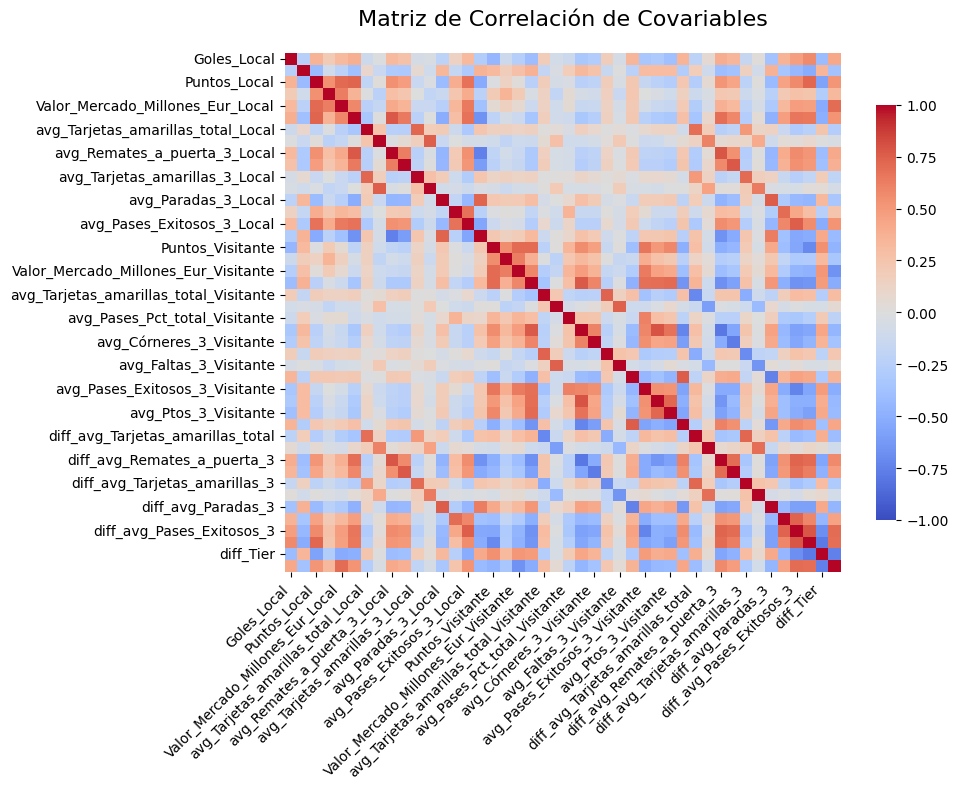

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

exclude = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis', 'Resultado_1X2', 'Tipo_Equipo',
    'Continente_Local', 'Continente_Visitante', 'Prob_Implicita_ELO'
]

# 1. Calcular la matriz de correlación (método de Pearson por defecto)
covariables = [x for x in df_reduced.columns if x not in exclude]
matriz_corr = df_reduced[covariables].corr()

# 3. Configurar el tamaño del lienzo (hazlo más grande si tienes muchas variables)
plt.figure(figsize=(10, 8))

# 4. Dibujar el Heatmap con Seaborn
sns.heatmap(
    matriz_corr,
    cmap="coolwarm",       # Paleta clásica: Rojo (correlación positiva), Azul (negativa)
    vmin=-1, vmax=1,       # Fija los límites de la escala de color estandarizada
    cbar_kws={"shrink": .8} # Ajusta el tamaño de la barra lateral de leyenda
)

# 5. Títulos y ajustes finales
plt.title("Matriz de Correlación de Covariables", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Rota las etiquetas de abajo para que se lean bien
plt.tight_layout()
plt.show()

In [ ]:
# Elimina columnas que contengan 'avg_Peso_2' o 'avg_Peso_5' ya que son redundantes (el Peso es constante)
pattern = r'avg_Peso_2|avg_Peso_3|avg_Peso_5|Puntos_Local|Puntos_Visitante|Valor_Mercado_Millones_Eur_'
df_reduced = df_reduced.loc[:, ~df_reduced.columns.str.contains(pattern, regex=True)]
print(df_reduced.shape)
df_reduced.tail()

(1420, 45)


,Fecha,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Peso_Local,avg_Goles_esperados_(xG)_total_Local,avg_Tarjetas_amarillas_total_Local,avg_Faltas_total_Local,avg_Remates_a_puerta_3_Local,avg_Córneres_3_Local,avg_Tarjetas_amarillas_3_Local,avg_Faltas_3_Local,avg_Paradas_3_Local,avg_Pases_Pct_3_Local,avg_Pases_Exitosos_3_Local,avg_Paradas_Share_3_Local,Peso_Visitante,Resultado_1X2,avg_Goles_esperados_(xG)_total_Visitante,avg_Tarjetas_amarillas_total_Visitante,avg_Faltas_total_Visitante,avg_Pases_Pct_total_Visitante,avg_Remates_a_puerta_3_Visitante,avg_Córneres_3_Visitante,avg_Tarjetas_amarillas_3_Visitante,avg_Faltas_3_Visitante,avg_Paradas_3_Visitante,avg_Pases_Exitosos_3_Visitante,avg_Goles_3_Visitante,avg_Ptos_3_Visitante,avg_Paradas_Share_3_Visitante,diff_avg_Tarjetas_amarillas_total,diff_avg_Faltas_total,diff_avg_Remates_a_puerta_3,diff_avg_Córneres_3,diff_avg_Tarjetas_amarillas_3,diff_avg_Faltas_3,diff_avg_Paradas_3,diff_avg_Pases_Pct_3,diff_avg_Pases_Exitosos_3,diff_Puntos,Prob_Implicita_ELO,diff_Tier,diff_Valor_Mercado
1415,2026-06-17,Austria,Jordania,NaN,NaN,1.0,1.788936,1.704255,12.234043,3.666667,4.333333,1.000000,12.000000,0.666667,0.856667,455.666667,0.333333,0.70,2,1.264321,1.785714,11.578571,0.745429,2.333333,6.666667,2.000000,11.766667,2.500000,261.366667,1.333333,0.666667,0.641682,-0.081459,0.655471,1.333333,-2.333333,-1.000000,0.233333,-1.833333,0.086000,194.300000,202.00,0.761842,-1,8.649
1416,2026-06-17,Inglaterra,Croacia,NaN,NaN,1.0,1.952442,1.373077,9.192308,5.333333,7.666667,1.000000,8.000000,1.333333,0.903333,568.000000,0.208333,1.00,2,1.854981,1.637037,10.833333,0.876481,4.333333,3.000000,2.333333,15.666667,3.666667,442.000000,2.000000,2.000000,0.631746,-0.263960,-1.641026,1.000000,4.666667,-1.333333,-7.666667,-2.333333,0.006667,126.000000,108.90,0.651781,0,37.340
1417,2026-06-17,Portugal,RD Congo,NaN,NaN,1.0,2.231056,1.837037,10.462963,7.333333,6.333333,0.666667,7.333333,1.666667,0.896667,567.666667,0.325397,0.60,2,1.344600,1.284000,14.880000,0.819360,3.666667,4.666667,0.966667,18.666667,2.333333,403.000000,1.000000,1.666667,0.432540,0.553037,-4.417037,3.666667,1.666667,-0.300000,-11.333333,-0.666667,0.056667,164.666667,285.48,0.837991,-3,33.140
1418,2026-06-18,Ghana,Panamá,NaN,NaN,0.6,1.218433,1.700000,13.666667,1.666667,3.333333,2.000000,8.333333,4.000000,0.833333,281.666667,0.888889,0.75,2,1.319222,1.713889,13.916667,0.822333,2.666667,1.000000,2.333333,13.000000,2.666667,245.333333,1.000000,1.333333,0.627778,-0.013889,-0.250000,-1.000000,2.333333,-0.333333,-4.666667,1.333333,0.040000,36.333333,-194.33,0.246261,1,7.680
1419,2026-06-18,Uzbekistán,Colombia,NaN,NaN,0.7,1.900259,1.829630,12.185185,4.000000,4.666667,1.900000,11.666667,4.000000,0.803333,318.000000,0.583333,0.95,2,1.439704,1.925926,14.185185,0.782593,6.333333,5.666667,0.333333,12.000000,2.666667,430.000000,2.666667,1.000000,0.386111,-0.096296,-2.000000,-2.333333,-1.000000,1.566667,-0.333333,1.333333,-0.056667,-112.000000,-227.75,0.212314,2,-8.360


## Guardar Datasets

In [ ]:
# --- Guardamos dataset del mundial

# 0. Añadir valor de mercado
valor_mercado_map = df_transfermarkt.set_index('Equipo')['Valor_Mercado_Millones_Eur']
long_df['Valor_Mercado_Millones_Eur'] = long_df['Equipo'].map(valor_mercado_map)

# 1. Definimos la fecha que actuará como frontera
fecha_corte = pd.to_datetime('2026-06-11')

# 2. Creamos el dataset con los datos DESPUÉS (o el mismo día) de la fecha de corte
df_mundial = long_df[long_df['Fecha'] >= fecha_corte].copy()

# 3. Creamos el dataset con los datos ANTES de la fecha de corte
df_reduced = df_reduced[df_reduced['Fecha'] < fecha_corte].copy()

# Comprobación de que no hemos perdido filas por el camino
print(f"Filas en df: {len(df_reduced)}")
print(f"Filas en df_mundial: {len(df_mundial)}")

Filas en df: 1396
Filas en df_mundial: 48


In [ ]:
df_reduced.to_csv(f'{base_path}/datos_historicos.csv', index=False)
df_mundial.to_csv(f'{base_path}/datos_mundial.csv', index=False)

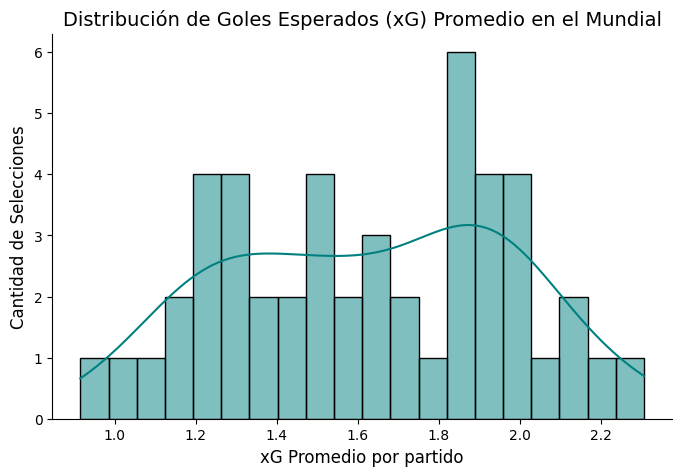

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el tamaño del gráfico para que se vea bien
plt.figure(figsize=(8, 5))

# histplot hace la magia: 'bins' son las barras, 'kde=True' dibuja la línea
sns.histplot(data=df_mundial,
             x='avg_Goles_esperados_(xG)_total',
             bins=20,
             kde=True,
             color='teal',
             edgecolor='black')

# Ponemos los títulos bonitos
plt.title('Distribución de Goles Esperados (xG) Promedio en el Mundial', fontsize=14)
plt.xlabel('xG Promedio por partido', fontsize=12)
plt.ylabel('Cantidad de Selecciones', fontsize=12)

# Quitamos las líneas feas de arriba y la derecha
sns.despine()

plt.show()